Here I want to try the 2D euclidean group: $SO(2)\ltimes \mathbb{R}^2$

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import random
from torch.utils.data import TensorDataset, DataLoader, random_split
import itertools
import math

import matplotlib.pyplot as plt

import os
import sys

random.seed(0)
pair_seed = 420

module_path = os.path.abspath(".")
if module_path not in sys.path:
    sys.path.append(module_path)

dtype = torch.float32

############## Use GPU ##############
USE_GPU = True
#####################################
if USE_GPU == True and torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print('using device:', device)

using device: cpu


In [3]:

def sample_se2_elements(n_samples, t_std=1.0, device="cpu", dtype=torch.float32):
    theta = 2 * math.pi * torch.rand(n_samples, device=device, dtype=dtype)
    c = torch.cos(theta)
    s = torch.sin(theta)
    t = t_std * torch.randn(n_samples, 2, device=device, dtype=dtype)
    return torch.cat([c[:, None], s[:, None], t], dim=1)


def se2_multiply(g1, g2):
    c1 = g1[:, 0]
    s1 = g1[:, 1]
    x1 = g1[:, 2]
    y1 = g1[:, 3]

    c2 = g2[:, 0]
    s2 = g2[:, 1]
    x2 = g2[:, 2]
    y2 = g2[:, 3]

    c12 = c1 * c2 - s1 * s2
    s12 = s1 * c2 + c1 * s2

    x12 = x1 + c1 * x2 - s1 * y2
    y12 = y1 + s1 * x2 + c1 * y2

    return torch.stack([c12, s12, x12, y12], dim=-1)


def make_se2_dataset(n_samples, t_std=1.0, device="cpu", dtype=torch.float32):
    g1 = sample_se2_elements(n_samples, t_std=t_std, device=device, dtype=dtype)
    g2 = sample_se2_elements(n_samples, t_std=t_std, device=device, dtype=dtype)
    y = se2_multiply(g1, g2)
    x = torch.cat([g1, g2], dim=1)
    return x, y

In [ ]:
def make_se2_fixed_bank_dataset(
    bank_size=128,
    train_fraction=0.1,
    t_std=1.0,
    device="cpu",
    dtype=torch.float32,
    seed=0,
):
    """
    Build a fixed-bank multiplication-table-style dataset.

    Returns:
        X_train, Y_train, X_test, Y_test, bank
    """
    torch.manual_seed(seed)

    # 1. Sample a fixed bank of group elements
    bank = sample_se2_elements(
        bank_size, t_std=t_std, device=device, dtype=dtype
    )

    # 2. Build all ordered pairs (g_i, g_j)
    idx_i = torch.arange(bank_size, device=device).repeat_interleave(bank_size)
    idx_j = torch.arange(bank_size, device=device).repeat(bank_size)

    g1 = bank[idx_i]   # shape (bank_size^2, 4)
    g2 = bank[idx_j]   # shape (bank_size^2, 4)

    # 3. Compute products
    y = se2_multiply(g1, g2)
    x = torch.cat([g1, g2], dim=1)   # shape (bank_size^2, 8)

    # 4. Randomly split PAIRS, not elements
    n_total = x.shape[0]
    perm = torch.randperm(n_total, device=device)
    n_train = int(train_fraction * n_total)

    train_idx = perm[:n_train]
    test_idx = perm[n_train:]

    X_train = x[train_idx].cpu()
    Y_train = y[train_idx].cpu()
    X_test = x[test_idx].cpu()
    Y_test = y[test_idx].cpu()
    bank = bank.cpu()

    return X_train, Y_train, X_test, Y_test, bank


def make_se2_dataset_from_bank(bank, train_fraction=0.1, seed=0):
    """
    Given a fixed bank of SE(2) elements, form all ordered pairs and split pairs
    into train/test.
    """
    torch.manual_seed(seed)

    bank = bank.cpu()
    bank_size = bank.shape[0]

    idx_i = torch.arange(bank_size).repeat_interleave(bank_size)
    idx_j = torch.arange(bank_size).repeat(bank_size)

    g1 = bank[idx_i]
    g2 = bank[idx_j]

    y = se2_multiply(g1, g2)
    x = torch.cat([g1, g2], dim=1)

    n_total = x.shape[0]
    perm = torch.randperm(n_total)
    n_train = int(train_fraction * n_total)

    train_idx = perm[:n_train]
    test_idx = perm[n_train:]

    X_train = x[train_idx]
    Y_train = y[train_idx]
    X_test = x[test_idx]
    Y_test = y[test_idx]

    return X_train, Y_train, X_test, Y_test

In [28]:
def make_se2_interval_bank(
    n_theta=9,
    n_x=5,
    n_y=5,
    theta_max=math.pi,
    x_max=1.0,
    y_max=1.0,
    device="cpu",
    dtype=torch.float32,
):
    """
    Build a deterministic SE(2) bank from intervals:
        theta in [-theta_max, theta_max]
        x in [-x_max, x_max]
        y in [-y_max, y_max]

    Each element is represented as:
        g = (cos(theta), sin(theta), x, y)

    Returns:
        bank: tensor of shape (n_theta * n_x * n_y, 4)
    """
    theta_vals = torch.linspace(-theta_max, theta_max, steps=n_theta, device=device, dtype=dtype)
    x_vals = torch.linspace(-x_max, x_max, steps=n_x, device=device, dtype=dtype)
    y_vals = torch.linspace(-y_max, y_max, steps=n_y, device=device, dtype=dtype)

    Theta, X, Y = torch.meshgrid(theta_vals, x_vals, y_vals, indexing="ij")

    c = torch.cos(Theta.reshape(-1))
    s = torch.sin(Theta.reshape(-1))
    x = X.reshape(-1)
    y = Y.reshape(-1)

    bank = torch.stack([c, s, x, y], dim=1)
    return bank

In [32]:
def make_se2_dataset_from_bank(bank, train_fraction=0.1, seed=0):
    """
    Given a fixed bank of SE(2) elements, form all ordered pairs and split pairs
    into train/test.
    """
    torch.manual_seed(seed)

    bank = bank.cpu()
    bank_size = bank.shape[0]

    idx_i = torch.arange(bank_size).repeat_interleave(bank_size)
    idx_j = torch.arange(bank_size).repeat(bank_size)

    g1 = bank[idx_i]
    g2 = bank[idx_j]

    y = se2_multiply(g1, g2)
    x = torch.cat([g1, g2], dim=1)

    n_total = x.shape[0]
    perm = torch.randperm(n_total)
    n_train = int(train_fraction * n_total)

    train_idx = perm[:n_train]
    test_idx = perm[n_train:]

    X_train = x[train_idx]
    Y_train = y[train_idx]
    X_test = x[test_idx]
    Y_test = y[test_idx]

    return X_train, Y_train, X_test, Y_test

In [29]:
class SE2MultiplierMLP(nn.Module):
    """
    One-hidden-layer MLP with internal embedding of each input group element.

    Input:
        x = concat(g1, g2), shape (batch, 8)
        each g = (cos(theta), sin(theta), x, y)

    Output:
        y_hat = predicted product, shape (batch, 4)
    """
    def __init__(self, in_dim=4, emb_dim=128, hidden_dim=256, use_cross_terms=False):
        super().__init__()
        self.use_cross_terms = use_cross_terms

        # embed each group element internally
        self.embed = nn.Linear(in_dim, emb_dim)

        if use_cross_terms:
            combined_dim = 4 * emb_dim   # z1, z2, z1*z2, z1-z2
        else:
            combined_dim = 2 * emb_dim   # z1, z2

        # one hidden layer total
        self.hidden = nn.Linear(combined_dim, hidden_dim)
        self.out = nn.Linear(hidden_dim, 4)

        #self.act = nn.tanh()

    def forward(self, x):
        g1 = x[:, :4]
        g2 = x[:, 4:]

        z1 = torch.tanh(self.embed(g1))
        z2 = torch.tanh(self.embed(g2))

        if self.use_cross_terms:
            z = torch.cat([z1, z2, z1 * z2, z1 - z2], dim=-1)
        else:
            z = torch.cat([z1, z2], dim=-1)

        h = torch.tanh(self.hidden(z))
        out = self.out(h)

        # normalize the SO(2) part onto the circle
        rot = out[:, :2]
        trans = out[:, 2:]
        rot = rot / (rot.norm(dim=-1, keepdim=True) + 1e-8)

        return torch.cat([rot, trans], dim=-1)

In [30]:
def se2_loss(y_hat, y, rot_weight=1.0, trans_weight=1.0):
    rot_loss = ((y_hat[:, :2] - y[:, :2]) ** 2).mean()
    trans_loss = ((y_hat[:, 2:] - y[:, 2:]) ** 2).mean()
    total = rot_weight * rot_loss + trans_weight * trans_loss
    return total, rot_loss, trans_loss


def train_model(
    model,
    train_loader,
    test_loader=None,
    epochs=200,
    lr=1e-3,
    weight_decay=1e-4,
    rot_weight=1.0,
    trans_weight=1.0,
    device="cpu",
    print_every=20,
):
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {
        "train_loss": [],
        "train_rot_loss": [],
        "train_trans_loss": [],
        "test_loss": [],
        "test_rot_loss": [],
        "test_trans_loss": [],
    }

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss_sum = 0.0
        train_rot_sum = 0.0
        train_trans_sum = 0.0
        n_train = 0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            y_hat = model(xb)
            loss, rot_loss, trans_loss = se2_loss(
                y_hat, yb,
                rot_weight=rot_weight,
                trans_weight=trans_weight,
            )
            loss.backward()
            optimizer.step()

            bs = xb.size(0)
            train_loss_sum += loss.item() * bs
            train_rot_sum += rot_loss.item() * bs
            train_trans_sum += trans_loss.item() * bs
            n_train += bs

        history["train_loss"].append(train_loss_sum / n_train)
        history["train_rot_loss"].append(train_rot_sum / n_train)
        history["train_trans_loss"].append(train_trans_sum / n_train)

        if test_loader is not None:
            model.eval()
            test_loss_sum = 0.0
            test_rot_sum = 0.0
            test_trans_sum = 0.0
            n_test = 0

            with torch.no_grad():
                for xb, yb in test_loader:
                    xb = xb.to(device)
                    yb = yb.to(device)

                    y_hat = model(xb)
                    loss, rot_loss, trans_loss = se2_loss(
                        y_hat, yb,
                        rot_weight=rot_weight,
                        trans_weight=trans_weight,
                    )

                    bs = xb.size(0)
                    test_loss_sum += loss.item() * bs
                    test_rot_sum += rot_loss.item() * bs
                    test_trans_sum += trans_loss.item() * bs
                    n_test += bs

            history["test_loss"].append(test_loss_sum / n_test)
            history["test_rot_loss"].append(test_rot_sum / n_test)
            history["test_trans_loss"].append(test_trans_sum / n_test)
        else:
            history["test_loss"].append(None)
            history["test_rot_loss"].append(None)
            history["test_trans_loss"].append(None)

        if epoch % print_every == 0 or epoch == 1 or epoch == epochs:
            msg = f"Epoch {epoch:4d} | train {history['train_loss'][-1]:.6f}"
            if test_loader is not None:
                msg += f" | test {history['test_loss'][-1]:.6f}"
            print(msg)

    return history

In [34]:
bank = make_se2_interval_bank(
    n_theta=9,
    n_x=5,
    n_y=5,
    theta_max=0.5,
    x_max=1.0,
    y_max=1.0,
)
X_train, Y_train, X_test, Y_test = make_se2_dataset_from_bank(
    bank,
    train_fraction=0.01,
    seed=0,
)

train_loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=256, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, Y_test), batch_size=512, shuffle=False)

model = SE2MultiplierMLP(
    in_dim=4,
    emb_dim=64,
    hidden_dim=256,
    use_cross_terms=False,
)

history = train_model(
    model,
    train_loader,
    test_loader=test_loader,
    epochs=2000,
    lr=1e-3,
    weight_decay=1e-2,
    device=device,
    print_every=100
)

Epoch    1 | train 1.942533 | test 1.106730
Epoch  100 | train 0.045169 | test 0.047668
Epoch  200 | train 0.006733 | test 0.008180
Epoch  300 | train 0.003066 | test 0.003961
Epoch  400 | train 0.002345 | test 0.003142
Epoch  500 | train 0.001864 | test 0.002565
Epoch  600 | train 0.001508 | test 0.002094
Epoch  700 | train 0.001220 | test 0.001690
Epoch  800 | train 0.000972 | test 0.001360
Epoch  900 | train 0.000799 | test 0.001090
Epoch 1000 | train 0.000639 | test 0.000880
Epoch 1100 | train 0.000520 | test 0.000729
Epoch 1200 | train 0.000403 | test 0.000591
Epoch 1300 | train 0.000307 | test 0.000477
Epoch 1400 | train 0.000228 | test 0.000383
Epoch 1500 | train 0.000171 | test 0.000307
Epoch 1600 | train 0.000149 | test 0.000267
Epoch 1700 | train 0.000200 | test 0.000240
Epoch 1800 | train 0.000275 | test 0.000289
Epoch 1900 | train 0.000108 | test 0.000227
Epoch 2000 | train 0.000128 | test 0.000295


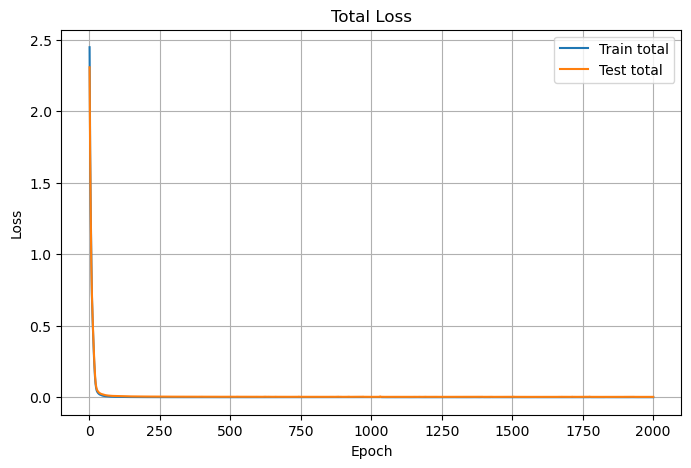

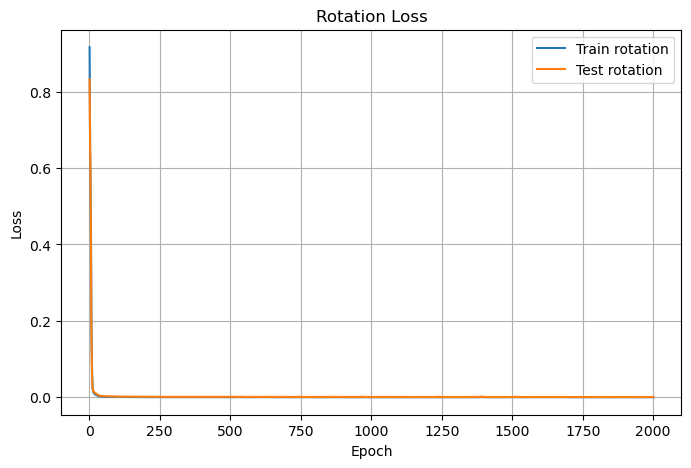

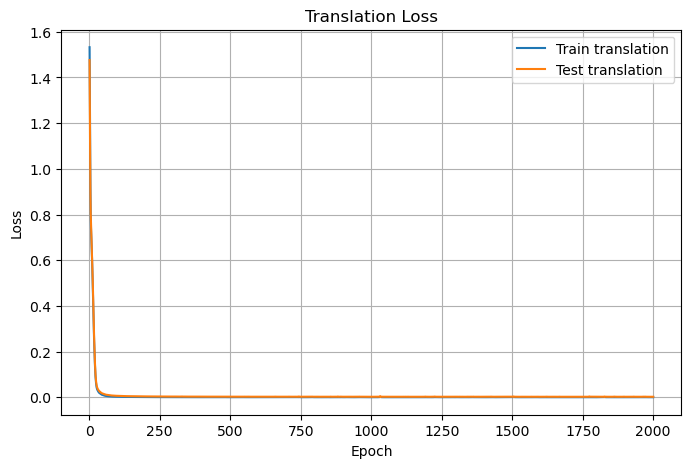

In [8]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_loss"], label="Train total")
if any(v is not None for v in history["test_loss"]):
    plt.plot(epochs, history["test_loss"], label="Test total")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Total Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_rot_loss"], label="Train rotation")
if any(v is not None for v in history["test_rot_loss"]):
    plt.plot(epochs, history["test_rot_loss"], label="Test rotation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Rotation Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_trans_loss"], label="Train translation")
if any(v is not None for v in history["test_trans_loss"]):
    plt.plot(epochs, history["test_trans_loss"], label="Test translation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Translation Loss")
plt.legend()
plt.grid(True)
plt.show()

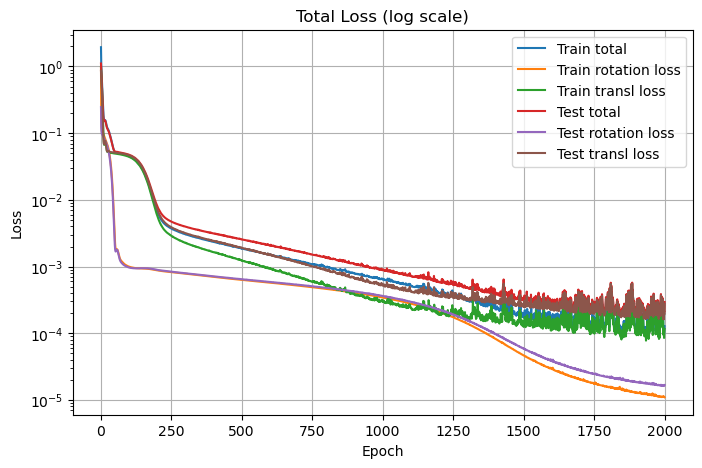

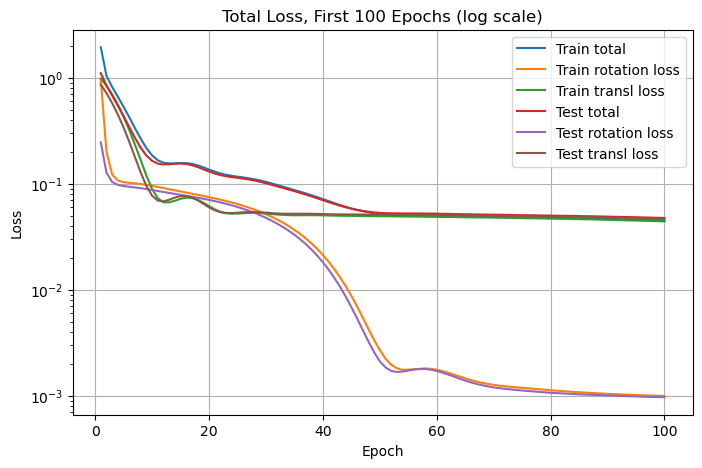

In [35]:
def plot_loss_better(history, zoom_epochs=100):
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    # Full plot, log y-scale
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_loss"], label="Train total")
    plt.plot(epochs, history["train_rot_loss"], label="Train rotation loss")
    plt.plot(epochs, history["train_trans_loss"], label="Train transl loss")
    if any(v is not None for v in history["test_loss"]):
        plt.plot(epochs, history["test_loss"], label="Test total")
        plt.plot(epochs, history["test_rot_loss"], label="Test rotation loss")
        plt.plot(epochs, history["test_trans_loss"], label="Test transl loss")
    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Total Loss (log scale)")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Zoomed early epochs
    plt.figure(figsize=(8, 5))
    plt.plot(epochs[:zoom_epochs], history["train_loss"][:zoom_epochs], label="Train total")
    plt.plot(epochs[:zoom_epochs], history["train_rot_loss"][:zoom_epochs], label="Train rotation loss")
    plt.plot(epochs[:zoom_epochs], history["train_trans_loss"][:zoom_epochs], label="Train transl loss")
    if any(v is not None for v in history["test_loss"]):
        plt.plot(epochs[:zoom_epochs], history["test_loss"][:zoom_epochs], label="Test total")
        plt.plot(epochs[:zoom_epochs], history["test_rot_loss"][:zoom_epochs], label="Test rotation loss")
        plt.plot(epochs[:zoom_epochs], history["test_trans_loss"][:zoom_epochs], label="Test transl loss")
    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Total Loss, First {zoom_epochs} Epochs (log scale)")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_loss_better(history)